Found 3 files:

16-51-18_Cavity_Spec_stark_shift_2D_Flux.hdf5
17-15-59_Cavity_Spec_stark_shift_2D_Flux.hdf5
18-03-46_Cavity_Spec_stark_shift_2D_Flux.hdf5
Loading 16-51-18_Cavity_Spec_stark_shift_2D_Flux.hdf5  Flux = 1.6 mA
    Magnitude shape: (15135, 101, 9)
    cavity_frequency shape: (101,)
    stark_ampx shape: (9,)
Loading 17-15-59_Cavity_Spec_stark_shift_2D_Flux.hdf5  Flux = 1.7 mA
    Magnitude shape: (27734, 101, 9)
    cavity_frequency shape: (101,)
    stark_ampx shape: (9,)
Loading 18-03-46_Cavity_Spec_stark_shift_2D_Flux.hdf5  Flux = 1.8 mA
    Magnitude shape: (42050, 101, 9)
    cavity_frequency shape: (101,)
    stark_ampx shape: (9,)

Combined shape: (3, 101, 9)
Expected: (8, 101, 9)
Color limits: 1.2019314474404482e-05 1.3001488553452593e-05


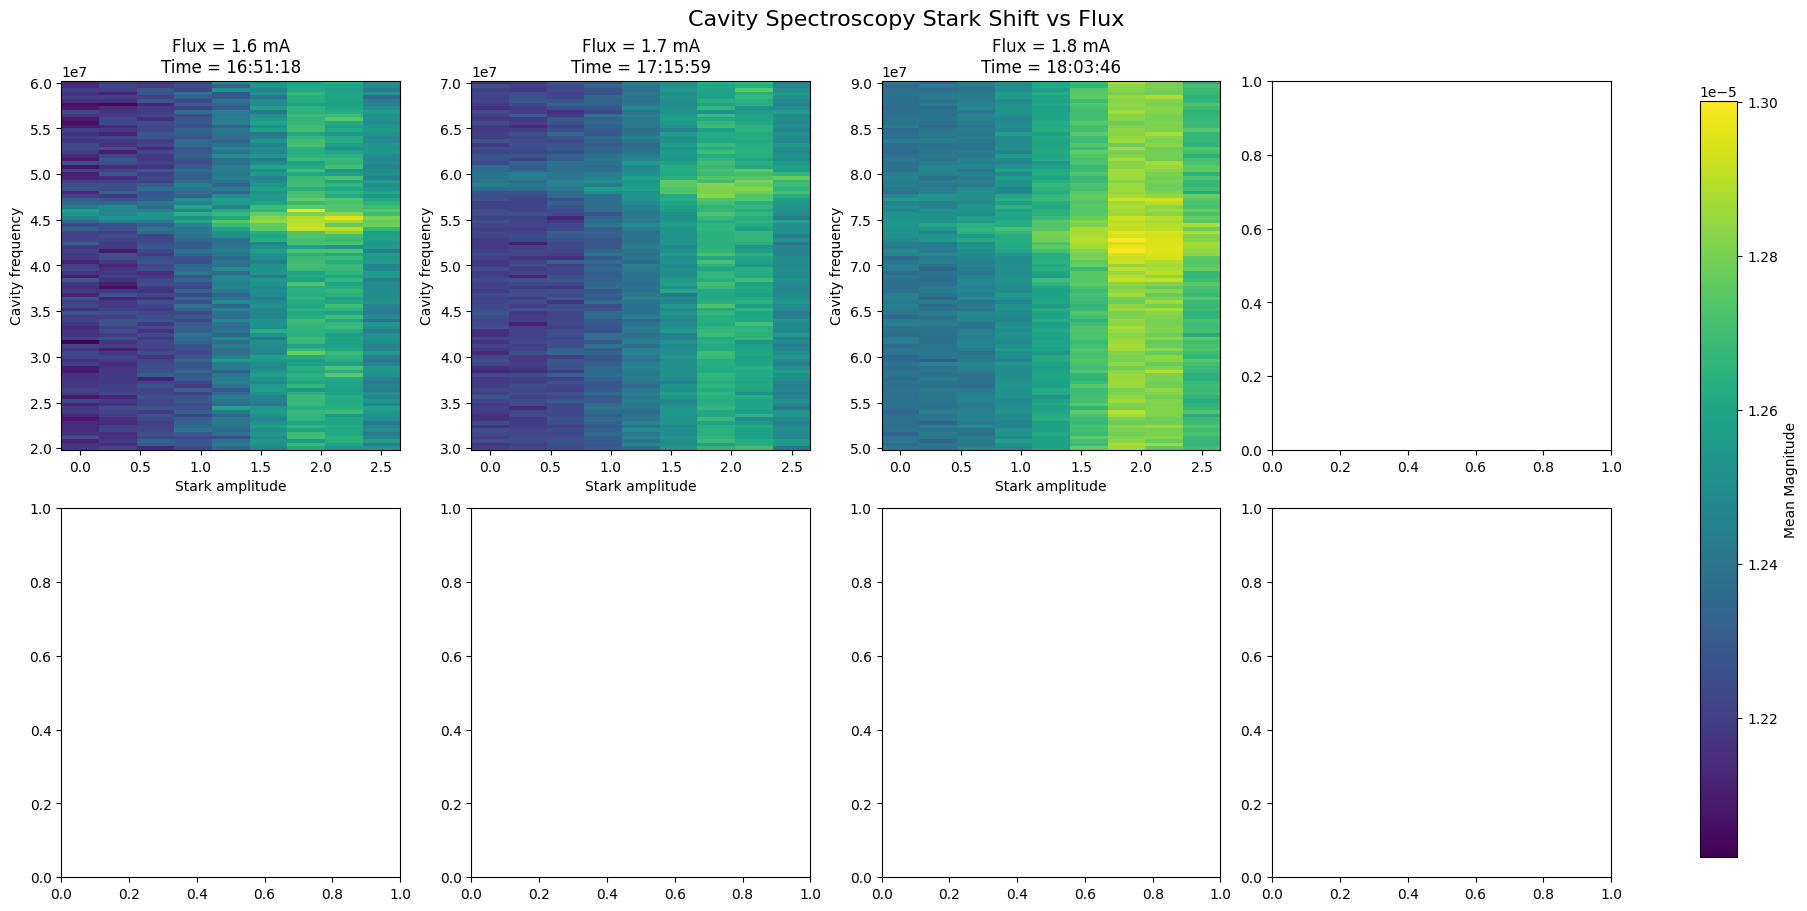

In [4]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# SETTINGS
# ==========================================================

import os
import re
from datetime import time


def collect_hdf5_files(
    folder,
    name_contains,
    start_time,
    end_time,
):
    """
    Collect HDF5 files whose names:

        1. start with HH-MM-SS
        2. contain `name_contains`
        3. fall between start_time and end_time

    Example:
        start_time = "18:20"
        end_time   = "21:59"
    """

    # ------------------------------------------------------
    # Convert "HH:MM" or "HH:MM:SS" -> datetime.time
    # ------------------------------------------------------

    def parse_time_string(s):
        parts = [int(x) for x in s.split(":")]

        if len(parts) == 2:
            return time(parts[0], parts[1], 0)

        elif len(parts) == 3:
            return time(parts[0], parts[1], parts[2])

        else:
            raise ValueError(
                "Time must be 'HH:MM' or 'HH:MM:SS'"
            )

    t_start = parse_time_string(start_time)
    t_end = parse_time_string(end_time)

    # ------------------------------------------------------
    # Search files
    # ------------------------------------------------------

    matched_files = []

    for filename in os.listdir(folder):

        # only HDF5
        if not filename.lower().endswith((".hdf5", ".h5")):
            continue

        # required name / experiment string
        if name_contains not in filename:
            continue

        # extract HH-MM-SS from beginning of filename
        match = re.match(
            r"^(\d{2})-(\d{2})-(\d{2})",
            filename
        )

        if match is None:
            continue

        hh, mm, ss = map(int, match.groups())
        file_time = time(hh, mm, ss)

        # --------------------------------------------------
        # Time selection
        # --------------------------------------------------

        if t_start <= file_time <= t_end:
            matched_files.append(
                (
                    file_time,
                    filename
                )
            )

    # chronological order
    matched_files.sort(key=lambda x: x[0])

    # return filenames only
    return [filename for _, filename in matched_files]


# ==========================================================
# USER SETTINGS
# ==========================================================

folder = r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-17"

name_contains = "Cavity_Spec_stark_shift_2D_Flux"

start_time = "16:51"
end_time   = "18:04"


# ==========================================================
# COLLECT FILES
# ==========================================================

filenames = collect_hdf5_files(
    folder=folder,
    name_contains=name_contains,
    start_time=start_time,
    end_time=end_time,
)


# ==========================================================
# SHOW RESULT
# ==========================================================

print(f"Found {len(filenames)} files:\n")

for filename in filenames:
    print(filename)

# Flux corresponding to each file
flux_values = np.linspace(start=1.6e-3, stop=2.5e-3, num=10)

# ==========================================================
# LOAD DATA
# ==========================================================

Z_all = []
freq_all = []
stark_all = []

for filename, flux in zip(filenames, flux_values):

    path = os.path.join(folder, filename)

    print(
        f"Loading {filename}  "
        f"Flux = {flux * 1e3:.1f} mA"
    )

    with h5py.File(path, "r") as f:

        magnitude = f["Magnitude"][()]
        cavity_frequency = f["cavity_frequency"][()]
        stark_ampx = f["stark_ampx"][()]

    print("    Magnitude shape:", magnitude.shape)
    print("    cavity_frequency shape:", cavity_frequency.shape)
    print("    stark_ampx shape:", stark_ampx.shape)

    # ------------------------------------------------------
    # Average over the 60000-sample waveform axis
    #
    # (60000, 101, 9) -> (101, 9)
    # ------------------------------------------------------

    Z = np.mean(magnitude, axis=0)

    Z_all.append(Z)
    freq_all.append(cavity_frequency)
    stark_all.append(stark_ampx)


Z_all = np.asarray(Z_all)

print()
print("Combined shape:", Z_all.shape)
print("Expected: (8, 101, 9)")


# ==========================================================
# GLOBAL COLOR SCALE
# ==========================================================
# Using the same color limits for every subplot makes the
# eight measurements directly comparable.
# ==========================================================

vmin = np.nanmin(Z_all)
vmax = np.nanmax(Z_all)

print("Color limits:", vmin, vmax)


# ==========================================================
# PLOT 2 x 4 SUBPLOTS
# ==========================================================

fig, axes = plt.subplots(
    2,
    4,
    figsize=(18, 9),
    constrained_layout=True,
)

axes = axes.ravel()

pcm = None

for i, (ax, filename, flux) in enumerate(
    zip(axes, filenames, flux_values)
):

    Z = Z_all[i]
    cavity_frequency = freq_all[i]
    stark_ampx = stark_all[i]

    pcm = ax.pcolormesh(
        stark_ampx,
        cavity_frequency,
        Z,
        shading="auto",
        vmin=vmin,
        vmax=vmax,
    )

    # Convert filename time:
    # 18-20-44 -> 18:20:44
    time_string = filename[:8].replace("-", ":")

    ax.set_title(
        f"Flux = {flux * 1e3:.1f} mA\n"
        f"Time = {time_string}"
    )

    ax.set_xlabel("Stark amplitude")
    ax.set_ylabel("Cavity frequency")


# ==========================================================
# ONE COLORBAR FOR ALL SUBPLOTS
# ==========================================================

cbar = fig.colorbar(
    pcm,
    ax=axes,
    label="Mean Magnitude",
    shrink=0.95,
)

fig.suptitle(
    "Cavity Spectroscopy Stark Shift vs Flux",
    fontsize=16,
)

plt.show()


Total: 18 files
  0:  current = 0.8 mA   2026-08-17  19:14:20
  1:  current = 0.9 mA   2026-08-17  20:49:07
  2:  current = 1.0 mA   2026-08-17  22:23:53
  3:  current = 1.1 mA   2026-08-17  23:58:39
  4:  current = 1.2 mA   2026-08-18  01:33:25
  5:  current = 1.3 mA   2026-08-18  03:08:12
  6:  current = 1.4 mA   2026-08-18  04:42:58
  7:  current = 1.5 mA   2026-08-18  06:17:45
  8:  current = 1.6 mA   2026-08-13  12:36:25
  9:  current = 1.7 mA   2026-08-13  12:51:31
 10:  current = 1.8 mA   2026-08-13  13:06:36
 11:  current = 1.9 mA   2026-08-13  13:21:41
 12:  current = 2.0 mA   2026-08-13  13:36:47
 13:  current = 2.1 mA   2026-08-13  13:51:54
 14:  current = 2.2 mA   2026-08-17  16:51:18
 15:  current = 2.3 mA   2026-08-17  17:15:59
 16:  current = 2.4 mA   2026-08-17  18:03:46
 17:  current = 2.5 mA   2026-08-18  07:52:34

Loading current = 0.8 mA
    2026-08-17 19-14-20_Cavity_Spec_stark_shift_2D_Flux.hdf5
    Magnitude shape: (60000, 101, 9)
    cavity_frequency shape: (10

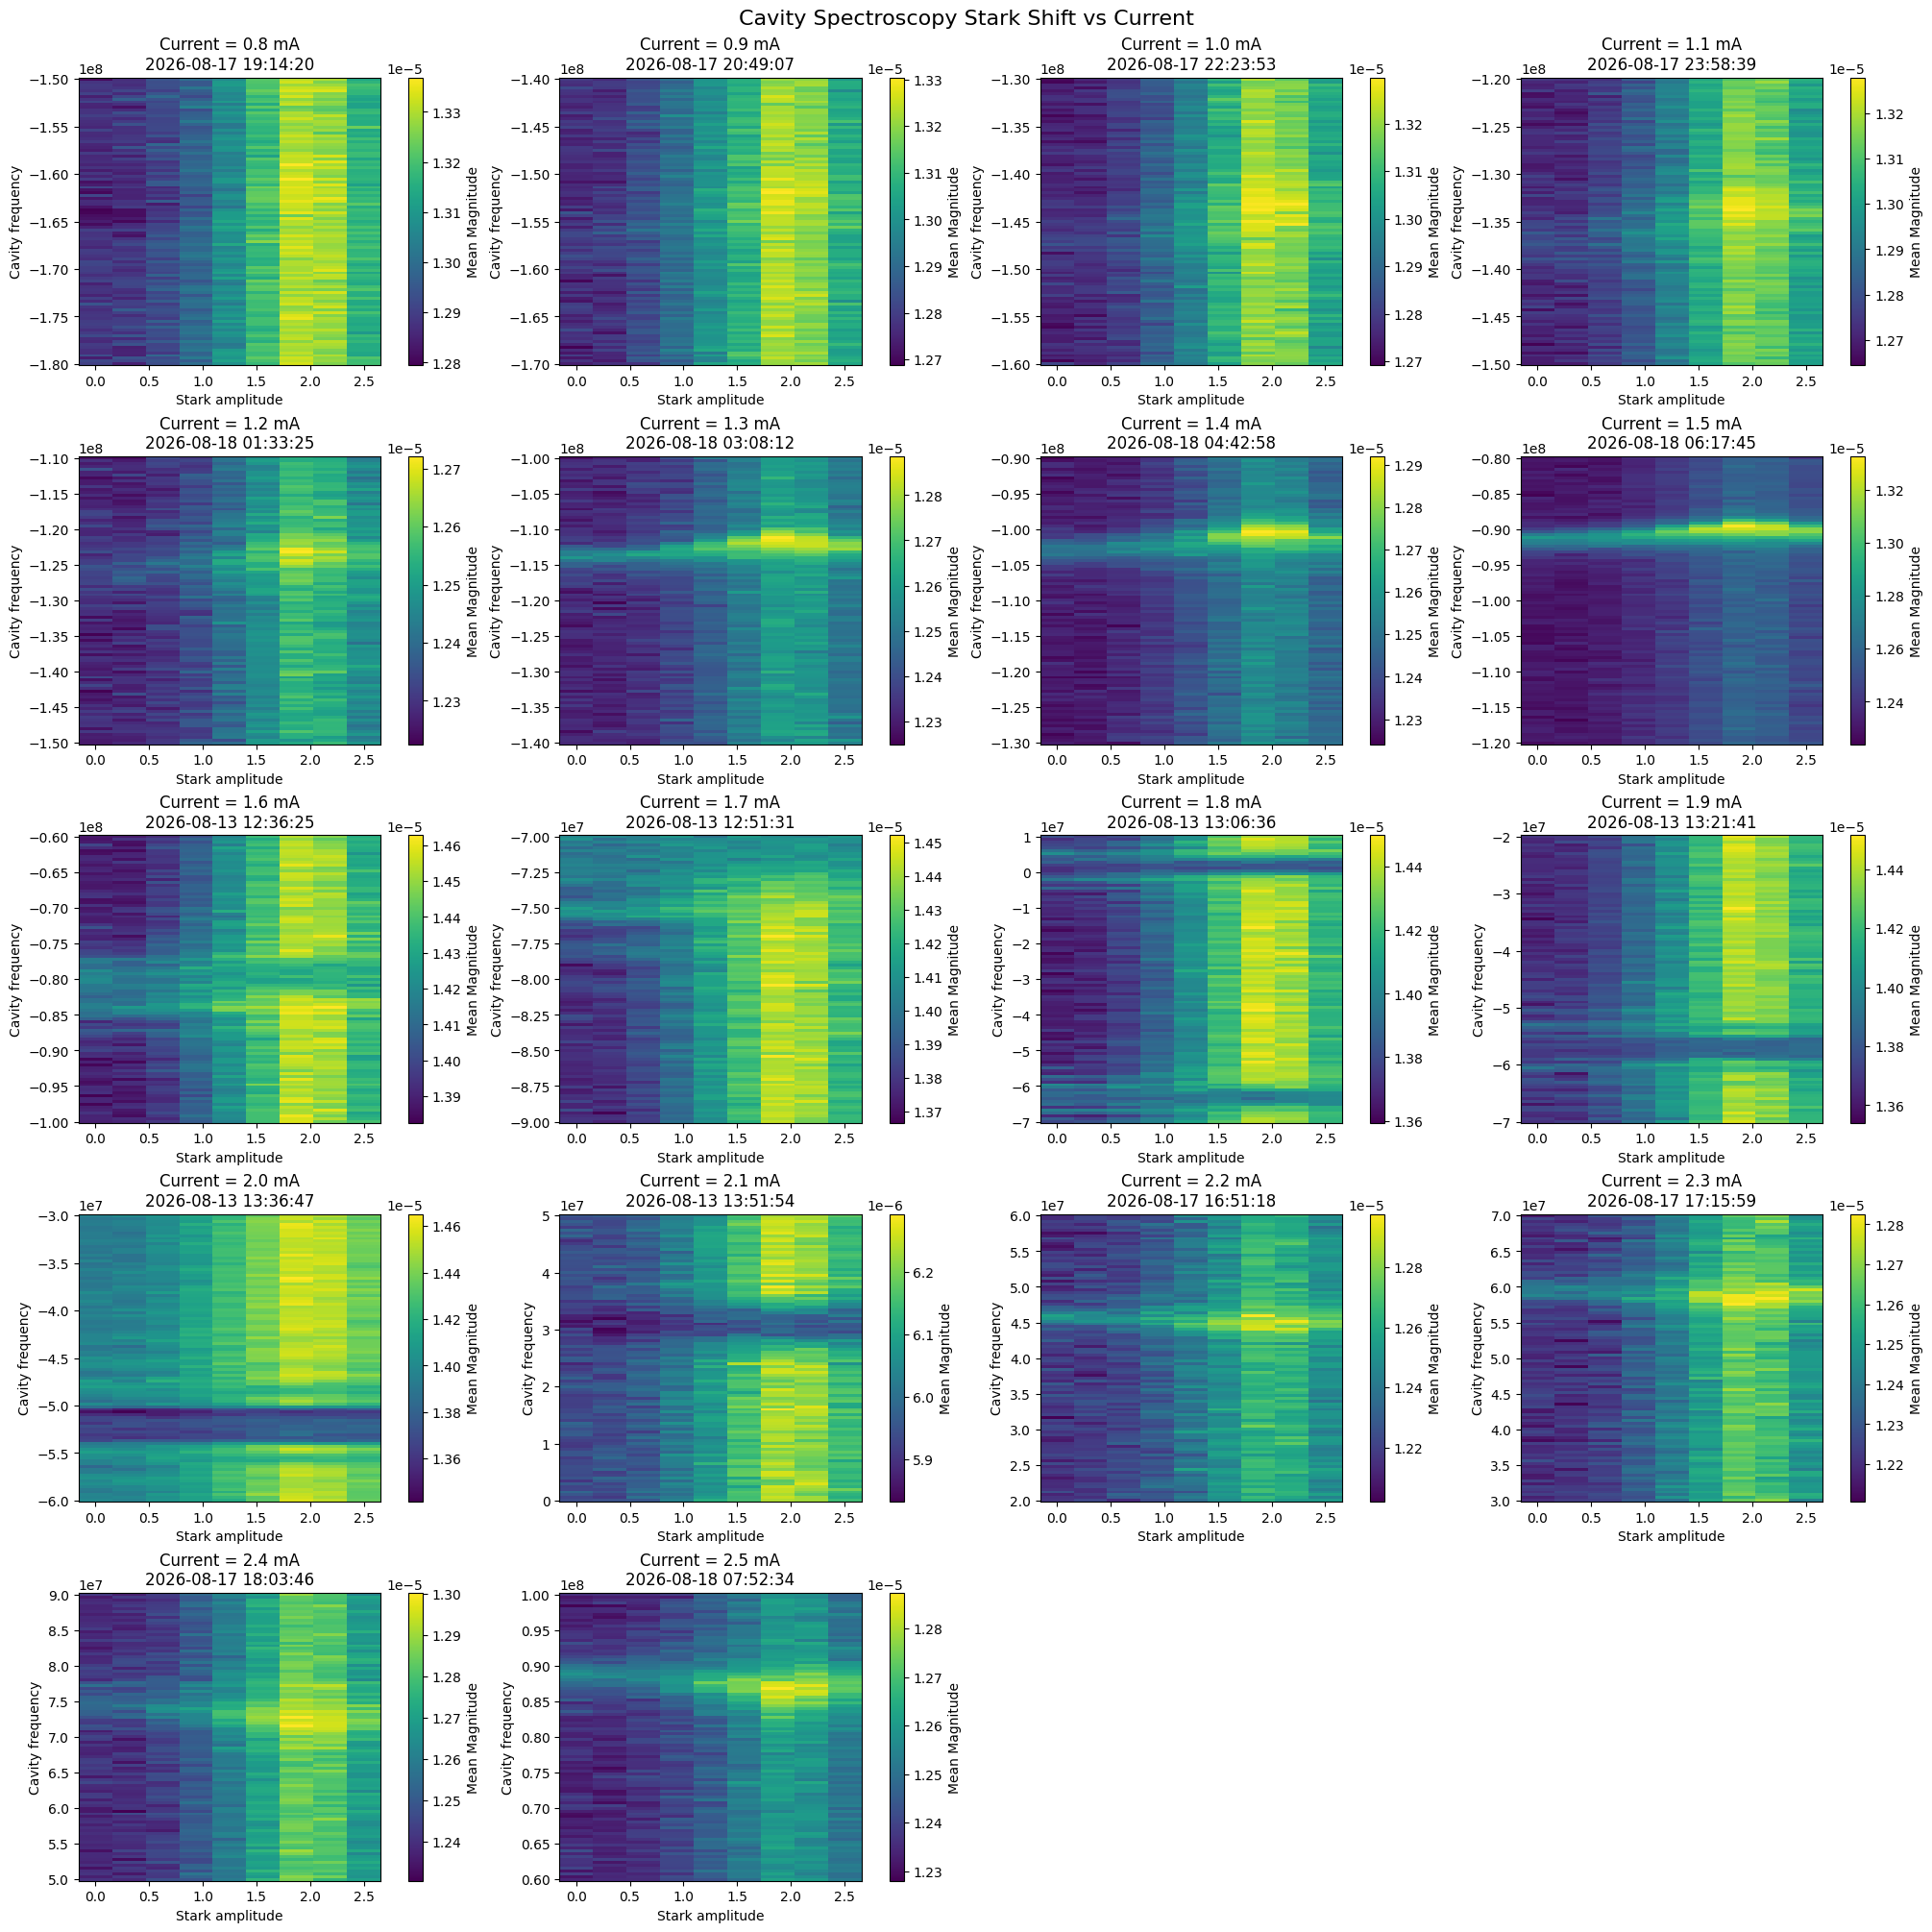


Saved NPZ:
C:\Users\qcrew\Desktop\Juncheng\victoria\scripts\plot\data_plot_data\CavitySpec_stark_shift_2D_current_0.8mA_to_2.5mA.npz

Z shape: (18, 101, 9)
frequency shape: (18, 101)
stark_ampx shape: (18, 9)
current shape: (18,)

Currents [mA]: [0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5]


In [9]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt


# ==========================================================
# CURRENT + FILE LIST
# ==========================================================

file_entries = [
    {
        "current_mA": 0.8,
        "path": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-17\19-14-20_Cavity_Spec_stark_shift_2D_Flux.hdf5",
    },
    {
        "current_mA": 0.9,
        "path": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-17\20-49-07_Cavity_Spec_stark_shift_2D_Flux.hdf5",
    },
    {
        "current_mA": 1.0,
        "path": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-17\22-23-53_Cavity_Spec_stark_shift_2D_Flux.hdf5",
    },
    {
        "current_mA": 1.1,
        "path": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-17\23-58-39_Cavity_Spec_stark_shift_2D_Flux.hdf5",
    },
    {
        "current_mA": 1.2,
        "path": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-18\01-33-25_Cavity_Spec_stark_shift_2D_Flux.hdf5",
    },
    {
        "current_mA": 1.3,
        "path": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-18\03-08-12_Cavity_Spec_stark_shift_2D_Flux.hdf5",
    },
    {
        "current_mA": 1.4,
        "path": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-18\04-42-58_Cavity_Spec_stark_shift_2D_Flux.hdf5",
    },
    {
        "current_mA": 1.5,
        "path": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-18\06-17-45_Cavity_Spec_stark_shift_2D_Flux.hdf5",
    },
    {
        "current_mA": 1.6,
        "path": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-13\12-36-25_Cavity_Spec_stark_shift_2D_Flux.hdf5",
    },
    {
        "current_mA": 1.7,
        "path": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-13\12-51-31_Cavity_Spec_stark_shift_2D_Flux.hdf5",
    },
    {
        "current_mA": 1.8,
        "path": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-13\13-06-36_Cavity_Spec_stark_shift_2D_Flux.hdf5",
    },
    {
        "current_mA": 1.9,
        "path": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-13\13-21-41_Cavity_Spec_stark_shift_2D_Flux.hdf5",
    },
    {
        "current_mA": 2.0,
        "path": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-13\13-36-47_Cavity_Spec_stark_shift_2D_Flux.hdf5",
    },
    {
        "current_mA": 2.1,
        "path": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-13\13-51-54_Cavity_Spec_stark_shift_2D_Flux.hdf5",
    },
    {
        "current_mA": 2.2,
        "path": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-17\16-51-18_Cavity_Spec_stark_shift_2D_Flux.hdf5",
    },
    {
        "current_mA": 2.3,
        "path": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-17\17-15-59_Cavity_Spec_stark_shift_2D_Flux.hdf5",
    },
    {
        "current_mA": 2.4,
        "path": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-17\18-03-46_Cavity_Spec_stark_shift_2D_Flux.hdf5",
    },
    {
        "current_mA": 2.5,
        "path": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-18\07-52-34_Cavity_Spec_stark_shift_2D_Flux.hdf5",
    },
]


# ==========================================================
# PREPARE METADATA
# ==========================================================

for entry in file_entries:

    path = entry["path"]

    entry["folder"] = os.path.dirname(path)
    entry["filename"] = os.path.basename(path)

    # Folder directly above filename is YYYY-MM-DD
    entry["date"] = os.path.basename(
        os.path.dirname(path)
    )


# ==========================================================
# SHOW FILES
# ==========================================================

n_files = len(file_entries)

print()
print("=" * 80)
print(f"Total: {n_files} files")
print("=" * 80)

for i, entry in enumerate(file_entries):

    time_string = (
        entry["filename"][:8]
        .replace("-", ":")
    )

    print(
        f"{i:3d}:  "
        f"current = {entry['current_mA']:.1f} mA   "
        f"{entry['date']}  "
        f"{time_string}"
    )


# ==========================================================
# CHECK FILES EXIST
# ==========================================================

for entry in file_entries:

    if not os.path.exists(entry["path"]):
        print(
            "WARNING: file not found:",
            entry["path"],
        )


# ==========================================================
# LOAD DATA
# ==========================================================

Z_all = []
freq_all = []
stark_all = []


for entry in file_entries:

    path = entry["path"]
    filename = entry["filename"]
    date = entry["date"]
    current_mA = entry["current_mA"]

    print()
    print(
        f"Loading current = {current_mA:.1f} mA"
    )
    print(
        f"    {date} {filename}"
    )

    with h5py.File(
        path,
        "r"
    ) as f:

        magnitude = f["Magnitude"][()]
        cavity_frequency = f["cavity_frequency"][()]
        stark_ampx = f["stark_ampx"][()]

    print(
        "    Magnitude shape:",
        magnitude.shape,
    )

    print(
        "    cavity_frequency shape:",
        cavity_frequency.shape,
    )

    print(
        "    stark_ampx shape:",
        stark_ampx.shape,
    )

    # ------------------------------------------------------
    # Average waveform/sample axis
    #
    # Example:
    # (60000, 101, 9) -> (101, 9)
    # ------------------------------------------------------

    Z = np.mean(
        magnitude,
        axis=0,
    )

    print(
        "    Averaged Z shape:",
        Z.shape,
    )

    Z_all.append(Z)
    freq_all.append(cavity_frequency)
    stark_all.append(stark_ampx)


# ==========================================================
# OPTIONAL GLOBAL COLOR SCALE
#
# Not currently used below because each subplot gets
# its own colorbar / color range.
# ==========================================================

vmin = min(
    np.nanmin(Z)
    for Z in Z_all
)

vmax = max(
    np.nanmax(Z)
    for Z in Z_all
)

print()
print(
    "Global color limits:",
    vmin,
    vmax,
)


# ==========================================================
# AUTOMATIC SUBPLOT GRID
# ==========================================================

ncols = min(
    4,
    n_files,
)

nrows = int(
    np.ceil(
        n_files / ncols
    )
)


# ==========================================================
# PLOT
# ==========================================================

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(
        5.0 * ncols,
        4.0 * nrows,
    ),
    constrained_layout=True,
)

axes = np.atleast_1d(
    axes
).ravel()


for i, (ax, entry) in enumerate(
    zip(
        axes,
        file_entries,
    )
):

    filename = entry["filename"]
    date = entry["date"]
    current_mA = entry["current_mA"]

    Z = Z_all[i]
    cavity_frequency = freq_all[i]
    stark_ampx = stark_all[i]

    # ------------------------------------------------------
    # Each plot gets its OWN color scale
    # ------------------------------------------------------

    pcm = ax.pcolormesh(
        stark_ampx,
        cavity_frequency,
        Z,
        shading="auto",
    )

    time_string = (
        filename[:8]
        .replace("-", ":")
    )

    ax.set_title(
        f"Current = {current_mA:.1f} mA\n"
        f"{date} {time_string}"
    )

    ax.set_xlabel(
        "Stark amplitude"
    )

    ax.set_ylabel(
        "Cavity frequency"
    )

    # ------------------------------------------------------
    # Separate colorbar for each subplot
    # ------------------------------------------------------

    cbar = fig.colorbar(
        pcm,
        ax=ax,
        pad=0.02,
    )

    cbar.set_label(
        "Mean Magnitude"
    )


# ==========================================================
# HIDE UNUSED SUBPLOTS
# ==========================================================

for ax in axes[n_files:]:
    ax.set_visible(False)


# ==========================================================
# TITLE
# ==========================================================

fig.suptitle(
    "Cavity Spectroscopy Stark Shift vs Current",
    fontsize=16,
)

plt.show()


# ==========================================================
# SAVE PROCESSED 2D DATA TO NPZ
# ==========================================================

current_min = min(entry["current_mA"] for entry in file_entries)
current_max = max(entry["current_mA"] for entry in file_entries)

save_path = os.path.join(
    r"C:\Users\qcrew\Desktop\Juncheng\victoria\scripts\plot\data_plot_data",
    f"CavitySpec_stark_shift_2D_current_{current_min:.1f}mA_to_{current_max:.1f}mA.npz",
)


# ==========================================================
# METADATA ARRAYS
# ==========================================================

currents_mA_saved = np.array([
    entry["current_mA"]
    for entry in file_entries
])

currents_A_saved = (
    currents_mA_saved * 1e-3
)

dates_saved = np.array([
    entry["date"]
    for entry in file_entries
])

filenames_saved = np.array([
    entry["filename"]
    for entry in file_entries
])

paths_saved = np.array([
    entry["path"]
    for entry in file_entries
])


# ==========================================================
# DATA ARRAYS
# ==========================================================

Z_save = np.asarray(
    Z_all
)

freq_save = np.asarray(
    freq_all
)

stark_save = np.asarray(
    stark_all
)


# ==========================================================
# SAVE
# ==========================================================

np.savez_compressed(
    save_path,

    # Main 2D data
    Z=Z_save,

    # Axes
    cavity_frequency=freq_save,
    stark_ampx=stark_save,

    # Current
    current_mA=currents_mA_saved,
    current_A=currents_A_saved,

    # Metadata
    dates=dates_saved,
    filenames=filenames_saved,
    paths=paths_saved,
)
# np.savez_compressed(
#     save_path,

#     # Main 2D data
#     Z=Z_save,

#     # Axes
#     cavity_frequency=freq_save,
#     stark_ampx=stark_save,

#     # Outer sweep
#     flux=currents_mA_saved,

#     # Metadata
#     dates=dates_saved,
#     filenames=filenames_saved,
# )

# ==========================================================
# SUMMARY
# ==========================================================

print()
print("=" * 70)
print("Saved NPZ:")
print(save_path)

print()
print(
    "Z shape:",
    Z_save.shape,
)

print(
    "frequency shape:",
    freq_save.shape,
)

print(
    "stark_ampx shape:",
    stark_save.shape,
)

print(
    "current shape:",
    currents_mA_saved.shape,
)

print()
print(
    "Currents [mA]:",
    currents_mA_saved,
)

Magnitude shape: (29988, 101, 9)
Magnitude min/max: 3.725290298461914e-09 4.621830528819686e-05
cavity_frequency shape: (101,)
cavity_frequency min/max: 20 20
stark_ampx shape: (9,)
stark_ampx min/max: 0.0 2.5
Z shape: (101, 9)
Z min/max: 1.2276422314869665e-05 1.2879356753460207e-05


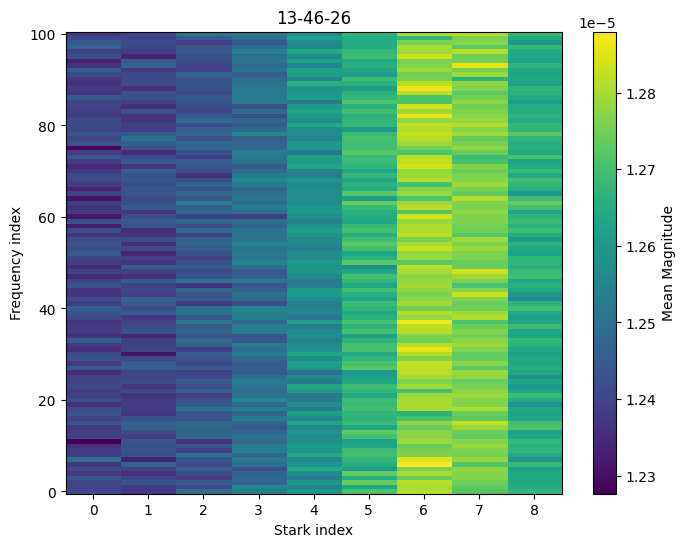

In [19]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

filepath = (
    r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-17"
    r"\13-46-26_Cavity_Spec_stark_shift_2D_Flux.hdf5"
)

with h5py.File(filepath, "r") as f:
    magnitude = f["Magnitude"][()]
    cavity_frequency = f["cavity_frequency"][()]
    stark_ampx = f["stark_ampx"][()]

print("Magnitude shape:", magnitude.shape)
print("Magnitude min/max:", np.nanmin(magnitude), np.nanmax(magnitude))

print("cavity_frequency shape:", cavity_frequency.shape)
print("cavity_frequency min/max:",
      np.nanmin(cavity_frequency),
      np.nanmax(cavity_frequency))

print("stark_ampx shape:", stark_ampx.shape)
print("stark_ampx min/max:",
      np.nanmin(stark_ampx),
      np.nanmax(stark_ampx))

Z = np.mean(magnitude, axis=0)

print("Z shape:", Z.shape)
print("Z min/max:", np.nanmin(Z), np.nanmax(Z))

plt.figure(figsize=(8, 6))

plt.imshow(
    Z,
    aspect="auto",
    origin="lower",
)

plt.colorbar(label="Mean Magnitude")
plt.xlabel("Stark index")
plt.ylabel("Frequency index")
plt.title("13-46-26")

plt.show()


2026-08-17: found 4 files

2026-08-18: found 4 files

2026-08-17: found 1 files

2026-08-17: found 1 files

2026-08-17: found 1 files

2026-08-18: found 1 files

Total: 12 files
  0:  2026-08-17  19:14:20  flux = 0.8000 mA
  1:  2026-08-17  20:49:07  flux = 0.9000 mA
  2:  2026-08-17  22:23:53  flux = 1.0000 mA
  3:  2026-08-17  23:58:39  flux = 1.1000 mA
  4:  2026-08-18  01:33:25  flux = 1.2000 mA
  5:  2026-08-18  03:08:12  flux = 1.3000 mA
  6:  2026-08-18  04:42:58  flux = 1.4000 mA
  7:  2026-08-18  06:17:45  flux = 1.5000 mA
  8:  2026-08-17  16:51:18  flux = 2.2000 mA
  9:  2026-08-17  17:15:59  flux = 2.3000 mA
 10:  2026-08-17  18:03:46  flux = 2.4000 mA
 11:  2026-08-18  07:52:34  flux = 2.5000 mA

Loading 2026-08-17 19-14-20_Cavity_Spec_stark_shift_2D_Flux.hdf5
Flux = 0.8000 mA
    Magnitude shape: (60000, 101, 9)
    cavity_frequency shape: (101,)
    stark_ampx shape: (9,)
    Averaged Z shape: (101, 9)

Loading 2026-08-17 20-49-07_Cavity_Spec_stark_shift_2D_Flux.hdf5
Fl

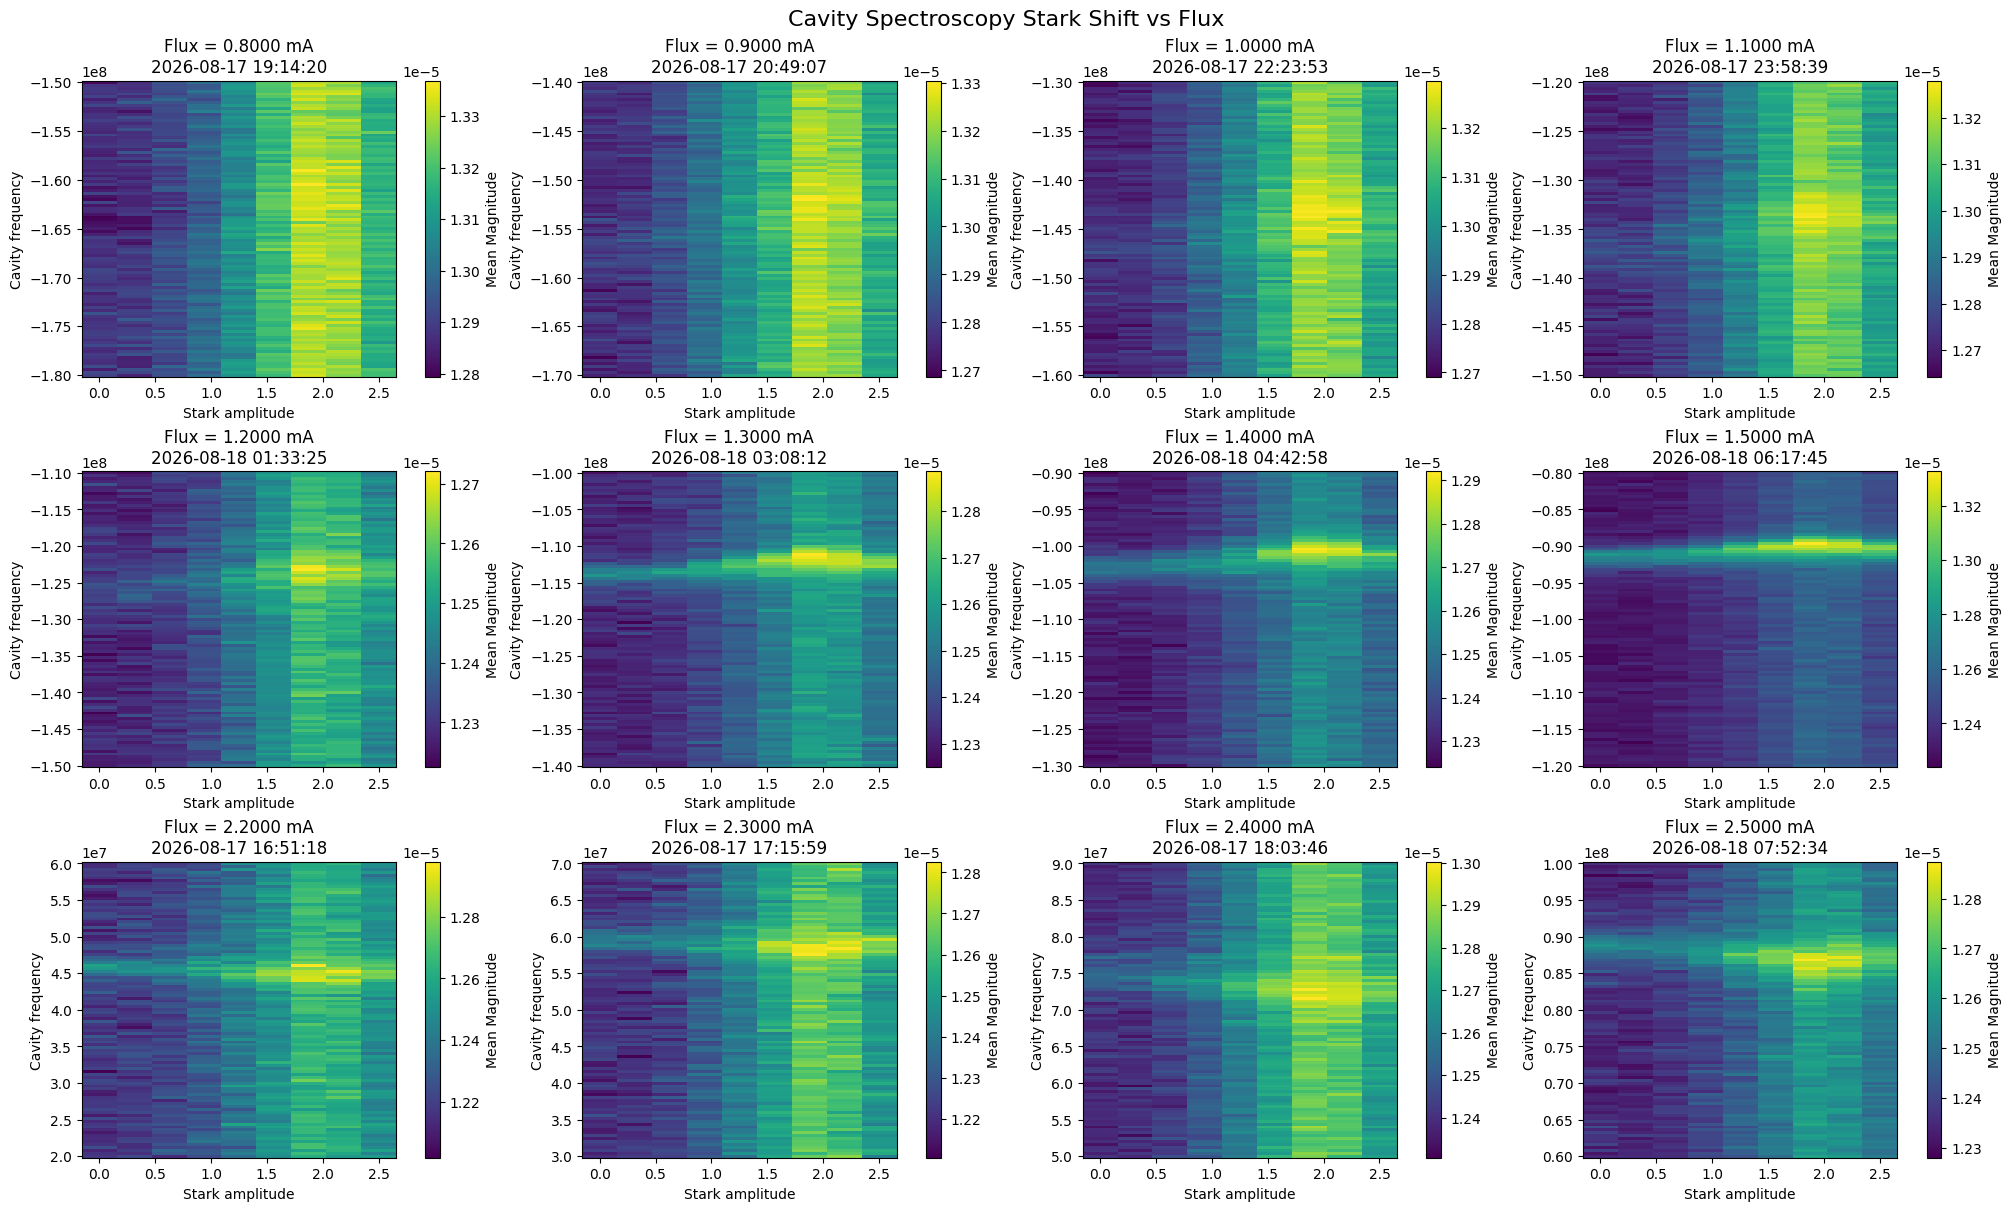


Saved NPZ:
C:\Users\qcrew\Desktop\Juncheng\victoria\data\CavitySpec_stark_shift_2D_flux_combined.npz
Z shape: (12, 101, 9)
frequency shape: (12, 101)
stark_ampx shape: (12, 9)
flux shape: (12,)


In [ ]:
import os
import re
from datetime import time

import h5py
import numpy as np
import matplotlib.pyplot as plt


# ==========================================================
# FUNCTIONS
# ==========================================================

def collect_hdf5_files(
    folder,
    name_contains,
    start_time,
    end_time,
):
    """
    Collect HDF5 files whose names:
        1. start with HH-MM-SS
        2. contain `name_contains`
        3. fall between start_time and end_time
    """

    def parse_time_string(s):
        parts = [int(x) for x in s.split(":")]

        if len(parts) == 2:
            return time(parts[0], parts[1], 0)

        elif len(parts) == 3:
            return time(parts[0], parts[1], parts[2])

        else:
            raise ValueError(
                "Time must be 'HH:MM' or 'HH:MM:SS'"
            )

    t_start = parse_time_string(start_time)
    t_end = parse_time_string(end_time)

    matched_files = []

    for filename in os.listdir(folder):

        if not filename.lower().endswith((".hdf5", ".h5")):
            continue

        if name_contains not in filename:
            continue

        match = re.match(
            r"^(\d{2})-(\d{2})-(\d{2})",
            filename
        )

        if match is None:
            continue

        hh, mm, ss = map(int, match.groups())
        file_time = time(hh, mm, ss)

        if t_start <= file_time <= t_end:
            matched_files.append(
                (
                    file_time,
                    filename,
                )
            )

    matched_files.sort(
        key=lambda x: x[0]
    )

    return [
        filename
        for _, filename in matched_files
    ]


# ==========================================================
# USER SETTINGS
# ==========================================================

name_contains = "Cavity_Spec_stark_shift_2D_Flux"


# Each batch can have a DIFFERENT:
#
#   date
#   folder
#   start/end time
#   flux_start
#   flux_stop
#
batches = [
    {
        "date": "2026-08-17",
        "folder": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-17",

        "start_time": "19:14",
        "end_time": "23:59",

        "flux_start": 0.8e-3,
        "flux_stop": 1.1e-3,
    },
    {
        "date": "2026-08-18",
        "folder": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-18",

        "start_time": "1:33",
        "end_time": "7:51",

        "flux_start": 1.2e-3,
        "flux_stop": 1.5e-3,
    },
    
    {
        "date": "2026-08-17",
        "folder": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-17",

        "start_time": "12:36",
        "end_time": "16:53",

        "flux_start": 1.6e-3,
        "flux_stop": 1.6e-3,
    },
    
    {
        "date": "2026-08-17",
        "folder": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-17",

        "start_time": "16:51",
        "end_time": "16:53",

        "flux_start": 2.2e-3,
        "flux_stop": 2.2e-3,
    },
    {
        "date": "2026-08-17",
        "folder": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-17",

        "start_time": "16:51",
        "end_time": "16:53",

        "flux_start": 2.2e-3,
        "flux_stop": 2.2e-3,
    },
    {
        "date": "2026-08-17",
        "folder": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-17",

        "start_time": "16:51",
        "end_time": "16:53",

        "flux_start": 2.2e-3,
        "flux_stop": 2.2e-3,
    },
    {
        "date": "2026-08-17",
        "folder": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-17",

        "start_time": "16:51",
        "end_time": "16:53",

        "flux_start": 2.2e-3,
        "flux_stop": 2.2e-3,
    },
    {
        "date": "2026-08-17",
        "folder": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-17",

        "start_time": "16:51",
        "end_time": "16:53",

        "flux_start": 2.2e-3,
        "flux_stop": 2.2e-3,
    },
    {
        "date": "2026-08-17",
        "folder": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-17",

        "start_time": "16:51",
        "end_time": "16:53",

        "flux_start": 2.2e-3,
        "flux_stop": 2.2e-3,
    },
    
    {
        "date": "2026-08-17",
        "folder": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-17",

        "start_time": "16:51",
        "end_time": "16:53",

        "flux_start": 2.2e-3,
        "flux_stop": 2.2e-3,
    },
    {
        "date": "2026-08-17",
        "folder": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-17",

        "start_time": "17:15",
        "end_time": "17:16",

        "flux_start": 2.3e-3,
        "flux_stop": 2.3e-3,
    },
    {
        "date": "2026-08-17",
        "folder": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-17",

        "start_time": "18:03",
        "end_time": "18:04",

        "flux_start": 2.4e-3,
        "flux_stop": 2.4e-3,
    },
    {
        "date": "2026-08-18",
        "folder": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-18",

        "start_time": "7:52",
        "end_time": "7:53",

        "flux_start": 2.5e-3,
        "flux_stop": 2.5e-3,
    },

    # {
    #     "date": "2026-08-15",
    #     "folder": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-15",

    #     "start_time": "00:00",
    #     "end_time": "13:30",

    #     "flux_start": 0.8e-3,
    #     "flux_stop": 1.5e-3,
    # },
]


# ==========================================================
# COLLECT FILES + ASSIGN FLUX FOR EACH BATCH
# ==========================================================

file_entries = []


for batch in batches:

    filenames_batch = collect_hdf5_files(
        folder=batch["folder"],
        name_contains=name_contains,
        start_time=batch["start_time"],
        end_time=batch["end_time"],
    )

    n_batch = len(filenames_batch)

    print()
    print(
        f"{batch['date']}: "
        f"found {n_batch} files"
    )

    if n_batch == 0:
        continue

    # ------------------------------------------------------
    # Flux values ONLY for this batch
    # ------------------------------------------------------

    flux_values_batch = np.linspace(
        start=batch["flux_start"],
        stop=batch["flux_stop"],
        num=n_batch,
    )

    # ------------------------------------------------------
    # Store filename + flux together
    # ------------------------------------------------------

    for filename, flux in zip(
        filenames_batch,
        flux_values_batch,
    ):

        file_entries.append(
            {
                "date": batch["date"],
                "folder": batch["folder"],
                "filename": filename,
                "flux": flux,
            }
        )


# ==========================================================
# SHOW FILES FOUND
# ==========================================================

n_files = len(file_entries)

print()
print("=" * 70)
print(
    f"Total: {n_files} files"
)
print("=" * 70)


for i, entry in enumerate(
    file_entries
):

    time_string = (
        entry["filename"][:8]
        .replace("-", ":")
    )

    print(
        f"{i:3d}:  "
        f"{entry['date']}  "
        f"{time_string}  "
        f"flux = {entry['flux'] * 1e3:.4f} mA"
    )


if n_files == 0:
    raise RuntimeError(
        "No matching HDF5 files were found."
    )


# ==========================================================
# LOAD DATA
# ==========================================================

Z_all = []
freq_all = []
stark_all = []


for entry in file_entries:

    filename = entry["filename"]
    folder = entry["folder"]
    date = entry["date"]
    flux = entry["flux"]

    path = os.path.join(
        folder,
        filename,
    )

    print()
    print(
        f"Loading {date} {filename}"
    )

    print(
        f"Flux = {flux * 1e3:.4f} mA"
    )

    with h5py.File(
        path,
        "r"
    ) as f:

        magnitude = f["Magnitude"][()]
        cavity_frequency = f["cavity_frequency"][()]
        stark_ampx = f["stark_ampx"][()]

    print(
        "    Magnitude shape:",
        magnitude.shape,
    )

    print(
        "    cavity_frequency shape:",
        cavity_frequency.shape,
    )

    print(
        "    stark_ampx shape:",
        stark_ampx.shape,
    )

    # ------------------------------------------------------
    # Average waveform/sample axis
    #
    # Example:
    # (60000, 101, 9) -> (101, 9)
    # ------------------------------------------------------

    Z = np.mean(
        magnitude,
        axis=0,
    )

    print(
        "    Averaged Z shape:",
        Z.shape,
    )

    Z_all.append(Z)
    freq_all.append(cavity_frequency)
    stark_all.append(stark_ampx)


# ==========================================================
# GLOBAL COLOR SCALE
# ==========================================================

vmin = min(
    np.nanmin(Z)
    for Z in Z_all
)

vmax = max(
    np.nanmax(Z)
    for Z in Z_all
)

print()
print(
    "Color limits:",
    vmin,
    vmax,
)


# ==========================================================
# AUTOMATIC SUBPLOT GRID
# ==========================================================

ncols = min(
    4,
    n_files,
)

nrows = int(
    np.ceil(
        n_files / ncols
    )
)


# ==========================================================
# AUTOMATIC SUBPLOT GRID
# ==========================================================

ncols = min(4, n_files)
nrows = int(np.ceil(n_files / ncols))


# ==========================================================
# PLOT
# ==========================================================

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(
        5.0 * ncols,
        4.0 * nrows,
    ),
    constrained_layout=True,
)

axes = np.atleast_1d(axes).ravel()


for i, (ax, entry) in enumerate(
    zip(axes, file_entries)
):

    filename = entry["filename"]
    date = entry["date"]
    flux = entry["flux"]

    Z = Z_all[i]
    print(Z)
    cavity_frequency = freq_all[i]
    stark_ampx = stark_all[i]

    # ------------------------------------------------------
    # Each plot automatically gets its OWN color scale
    # ------------------------------------------------------

    pcm = ax.pcolormesh(
        stark_ampx,
        cavity_frequency,
        Z,
        shading="auto",
    )

    time_string = filename[:8].replace("-", ":")

    ax.set_title(
        f"Flux = {flux * 1e3:.4f} mA\n"
        f"{date} {time_string}"
    )

    ax.set_xlabel("Stark amplitude")
    ax.set_ylabel("Cavity frequency")

    # ------------------------------------------------------
    # Separate colorbar for this subplot
    # ------------------------------------------------------

    cbar = fig.colorbar(
        pcm,
        ax=ax,
        pad=0.02,
    )

    cbar.set_label("Mean Magnitude")


# ==========================================================
# HIDE UNUSED SUBPLOTS
# ==========================================================

for ax in axes[n_files:]:
    ax.set_visible(False)


# ==========================================================
# TITLE
# ==========================================================

fig.suptitle(
    "Cavity Spectroscopy Stark Shift vs Flux",
    fontsize=16,
)

plt.show()

# ==========================================================
# SAVE PROCESSED 2D DATA TO NPZ
# ==========================================================

save_path = os.path.join(
    r"C:\Users\qcrew\Desktop\Juncheng\victoria\data",
    "CavitySpec_stark_shift_2D_flux_combined.npz",
)

# Convert metadata to arrays
dates = np.array([
    entry["date"]
    for entry in file_entries
])

filenames_saved = np.array([
    entry["filename"]
    for entry in file_entries
])

flux_values_saved = np.array([
    entry["flux"]
    for entry in file_entries
])

# If all measurements have the same shape, these become
# normal numeric arrays.
Z_save = np.asarray(Z_all)
freq_save = np.asarray(freq_all)
stark_save = np.asarray(stark_all)

np.savez_compressed(
    save_path,

    # Main 2D data
    Z=Z_save,

    # Axes
    cavity_frequency=freq_save,
    stark_ampx=stark_save,

    # Outer sweep
    flux=flux_values_saved,

    # Metadata
    dates=dates,
    filenames=filenames_saved,
)

print()
print("Saved NPZ:")
print(save_path)

print("Z shape:", Z_save.shape)
print("frequency shape:", freq_save.shape)
print("stark_ampx shape:", stark_save.shape)
print("flux shape:", flux_values_saved.shape)

Loading 12-36-25_Cavity_Spec_stark_shift_2D_Flux.hdf5  Flux = 1.6 mA
    Magnitude shape: (30000, 101, 9)
    cavity_frequency shape: (101,)
    stark_ampx shape: (9,)
Loading 12-51-31_Cavity_Spec_stark_shift_2D_Flux.hdf5  Flux = 1.7 mA
    Magnitude shape: (30000, 101, 9)
    cavity_frequency shape: (101,)
    stark_ampx shape: (9,)
Loading 13-06-36_Cavity_Spec_stark_shift_2D_Flux.hdf5  Flux = 1.8 mA
    Magnitude shape: (30000, 101, 9)
    cavity_frequency shape: (101,)
    stark_ampx shape: (9,)
Loading 13-21-41_Cavity_Spec_stark_shift_2D_Flux.hdf5  Flux = 1.9 mA
    Magnitude shape: (30000, 101, 9)
    cavity_frequency shape: (101,)
    stark_ampx shape: (9,)
Loading 13-36-47_Cavity_Spec_stark_shift_2D_Flux.hdf5  Flux = 2.0 mA
    Magnitude shape: (30000, 101, 9)
    cavity_frequency shape: (101,)
    stark_ampx shape: (9,)
Loading 13-51-54_Cavity_Spec_stark_shift_2D_Flux.hdf5  Flux = 2.1 mA
    Magnitude shape: (30000, 101, 9)
    cavity_frequency shape: (101,)
    stark_ampx shap

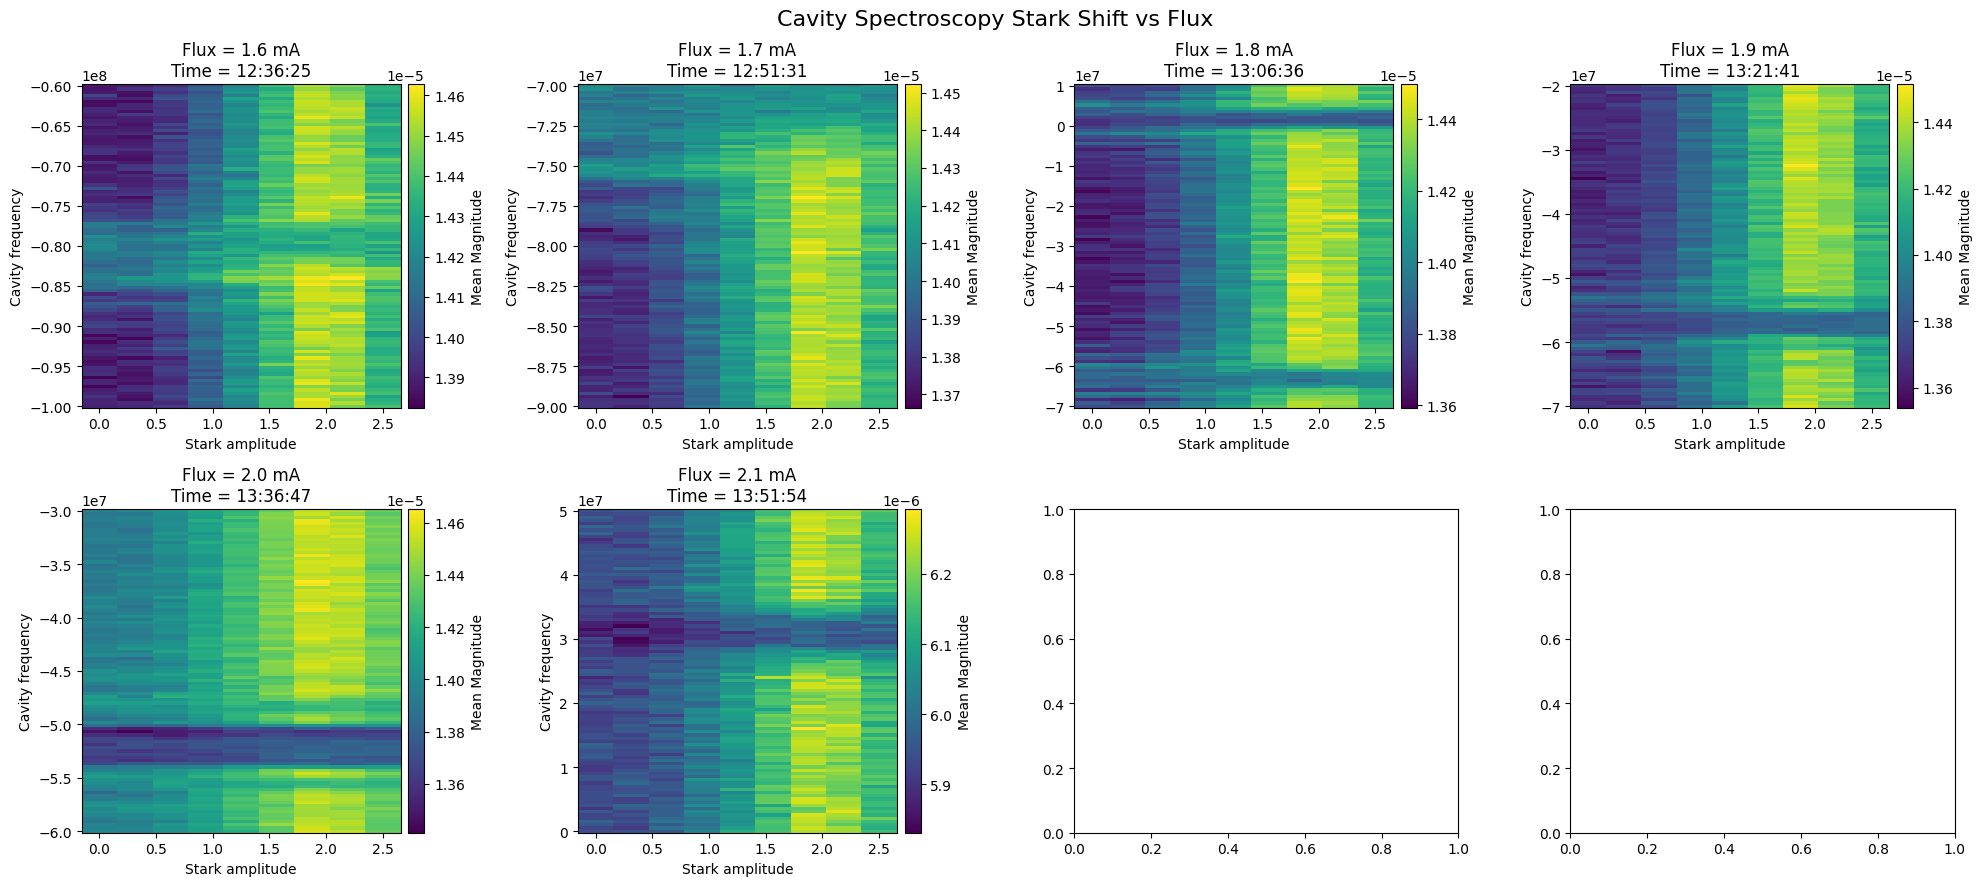

In [14]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# SETTINGS
# ==========================================================

# folder = r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-12"

# filenames = [
#     "18-20-44_Cavity_Spec_stark_shift_2D_Flux.hdf5",
#     "18-51-57_Cavity_Spec_stark_shift_2D_Flux.hdf5",
#     "19-23-10_Cavity_Spec_stark_shift_2D_Flux.hdf5",
#     "19-54-23_Cavity_Spec_stark_shift_2D_Flux.hdf5",
#     "20-25-36_Cavity_Spec_stark_shift_2D_Flux.hdf5",
#     "20-56-48_Cavity_Spec_stark_shift_2D_Flux.hdf5",
#     "21-28-01_Cavity_Spec_stark_shift_2D_Flux.hdf5",
#     "21-59-14_Cavity_Spec_stark_shift_2D_Flux.hdf5",
# ]

# flux_values = np.linspace(
#     start=0.8e-3,
#     stop=1.5e-3,
#     num=8,
# )

# ==========================================================
# LOAD DATA
# ==========================================================

Z_all = []
freq_all = []
stark_all = []

for filename, flux in zip(filenames, flux_values):

    path = os.path.join(folder, filename)

    print(
        f"Loading {filename}  "
        f"Flux = {flux * 1e3:.1f} mA"
    )

    with h5py.File(path, "r") as f:
        magnitude = f["Magnitude"][()]
        cavity_frequency = f["cavity_frequency"][()]
        stark_ampx = f["stark_ampx"][()]

    print("    Magnitude shape:", magnitude.shape)
    print("    cavity_frequency shape:", cavity_frequency.shape)
    print("    stark_ampx shape:", stark_ampx.shape)

    # (60000, 101, 9) -> (101, 9)
    Z = np.mean(magnitude, axis=0)

    Z_all.append(Z)
    freq_all.append(cavity_frequency)
    stark_all.append(stark_ampx)

Z_all = np.asarray(Z_all)

print()
print("Combined shape:", Z_all.shape)


# ==========================================================
# PLOT 2 x 4 SUBPLOTS
# EACH SUBPLOT HAS ITS OWN COLOR SCALE
# ==========================================================

fig, axes = plt.subplots(
    2,
    4,
    figsize=(20, 9),
)

axes = axes.ravel()

for i, (ax, filename, flux) in enumerate(
    zip(axes, filenames, flux_values)
):

    Z = Z_all[i]
    cavity_frequency = freq_all[i]
    stark_ampx = stark_all[i]

    # ------------------------------------------------------
    # Individual color scale automatically determined
    # from this dataset only
    # ------------------------------------------------------

    pcm = ax.pcolormesh(
        stark_ampx,
        cavity_frequency,
        Z,
        shading="auto",
    )

    # individual colorbar
    cbar = fig.colorbar(
        pcm,
        ax=ax,
        pad=0.02,
    )

    cbar.set_label("Mean Magnitude")

    # filename time: 18-20-44 -> 18:20:44
    time_string = filename[:8].replace("-", ":")

    ax.set_title(
        f"Flux = {flux * 1e3:.1f} mA\n"
        f"Time = {time_string}"
    )

    ax.set_xlabel("Stark amplitude")
    ax.set_ylabel("Cavity frequency")


fig.suptitle(
    "Cavity Spectroscopy Stark Shift vs Flux",
    fontsize=16,
)

plt.tight_layout()
plt.show()

In [4]:
import os
import re
import h5py
import numpy as np
import matplotlib.pyplot as plt
from datetime import time

# ==========================================================
# SETTINGS
# ==========================================================

folder = r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-12"

start_time = time(18, 20)
end_time   = time(21, 59, 59)


# ==========================================================
# FIND ALL HDF5 FILES IN TIME RANGE
# ==========================================================

files = []

for filename in os.listdir(folder):

    if not filename.lower().endswith((".hdf5", ".h5")):
        continue

    # Expect filename beginning with HH-MM-SS
    match = re.match(r"(\d{2})-(\d{2})-(\d{2})", filename)

    if match is None:
        continue

    hh, mm, ss = map(int, match.groups())
    file_time = time(hh, mm, ss)

    if start_time <= file_time <= end_time:
        files.append(
            (
                file_time,
                os.path.join(folder, filename)
            )
        )

# sort chronologically
files.sort(key=lambda x: x[0])

print(f"Found {len(files)} files:\n")

for t, path in files:
    print(t, os.path.basename(path))


# ==========================================================
# SHOW HDF5 KEYS / SHAPES FOR EVERY FILE
# ==========================================================

for t, path in files:

    print("\n")
    print("=" * 100)
    print(t, os.path.basename(path))
    print("=" * 100)

    try:
        with h5py.File(path, "r") as f:

            def show_item(name, obj):
                if isinstance(obj, h5py.Dataset):
                    print(
                        f"{name:30s} "
                        f"shape={str(obj.shape):20s} "
                        f"dtype={obj.dtype}"
                    )

            f.visititems(show_item)

    except Exception as e:
        print("ERROR:", e)
        
all_mag = []
all_freq = []
all_stark = []
all_filenames = []

for t, path in files:

    with h5py.File(path, "r") as f:

        # only use files containing these datasets
        if not all(k in f for k in ["Magnitude", "cavity_frequency", "stark_ampx"]):
            continue

        mag = f["Magnitude"][()]
        freq = f["cavity_frequency"][()]
        stark = f["stark_ampx"][()]

        print(
            os.path.basename(path),
            "Magnitude:", mag.shape,
            "freq:", freq.shape,
            "stark:", stark.shape,
        )

        all_mag.append(mag)
        all_freq.append(freq)
        all_stark.append(stark)
        all_filenames.append(os.path.basename(path))

Found 8 files:

18:20:44 18-20-44_Cavity_Spec_stark_shift_2D_Flux.hdf5
18:51:57 18-51-57_Cavity_Spec_stark_shift_2D_Flux.hdf5
19:23:10 19-23-10_Cavity_Spec_stark_shift_2D_Flux.hdf5
19:54:23 19-54-23_Cavity_Spec_stark_shift_2D_Flux.hdf5
20:25:36 20-25-36_Cavity_Spec_stark_shift_2D_Flux.hdf5
20:56:48 20-56-48_Cavity_Spec_stark_shift_2D_Flux.hdf5
21:28:01 21-28-01_Cavity_Spec_stark_shift_2D_Flux.hdf5
21:59:14 21-59-14_Cavity_Spec_stark_shift_2D_Flux.hdf5


18:20:44 18-20-44_Cavity_Spec_stark_shift_2D_Flux.hdf5
I                              shape=(60000, 101, 9)      dtype=float64
Magnitude                      shape=(60000, 101, 9)      dtype=float64
Q                              shape=(60000, 101, 9)      dtype=float64
cavity_frequency               shape=(101,)               dtype=int32
stark_ampx                     shape=(9,)                 dtype=float64


18:51:57 18-51-57_Cavity_Spec_stark_shift_2D_Flux.hdf5
I                              shape=(60000, 101, 9)      dtype=float64


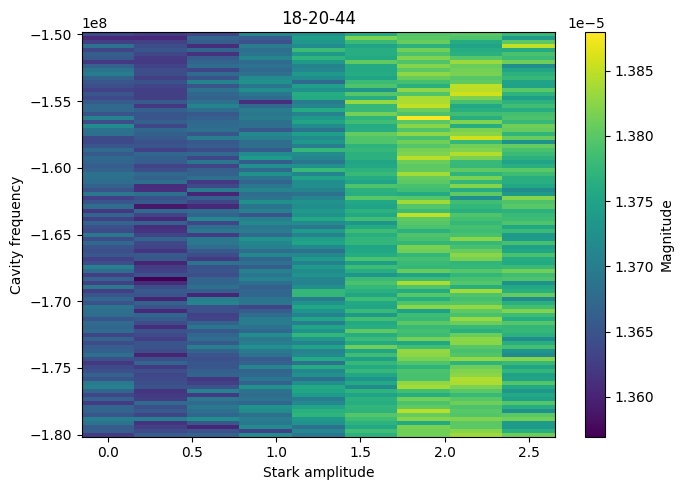

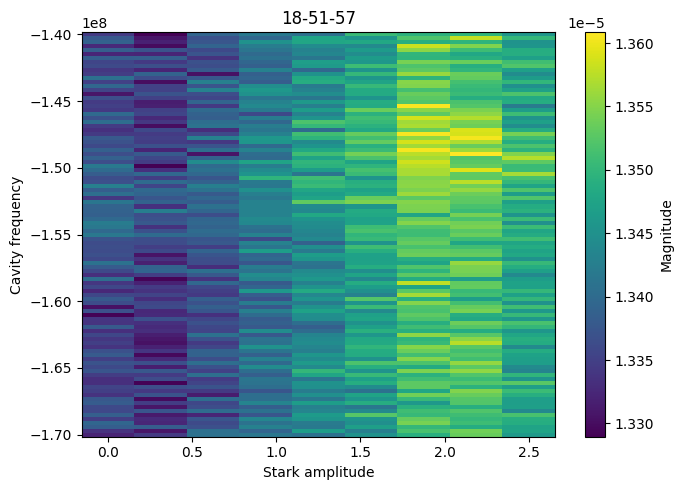

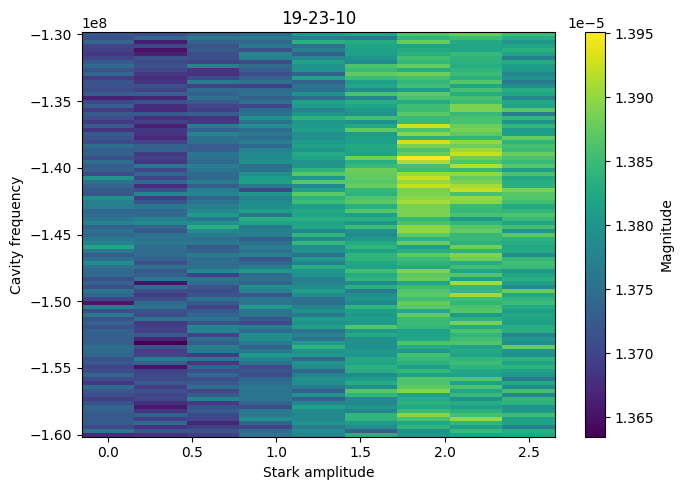

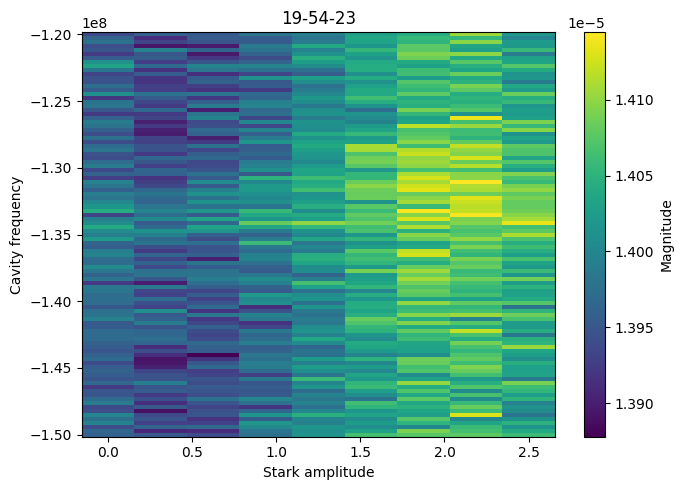

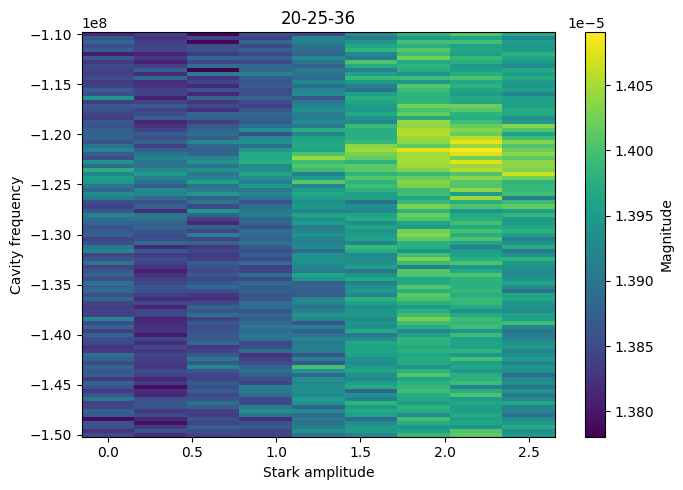

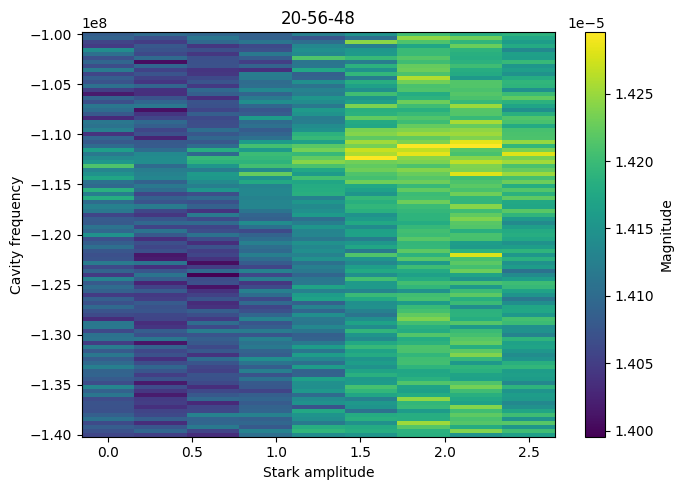

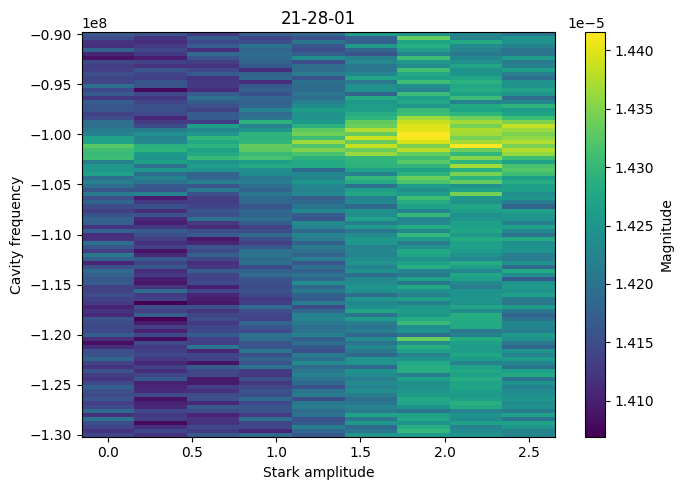

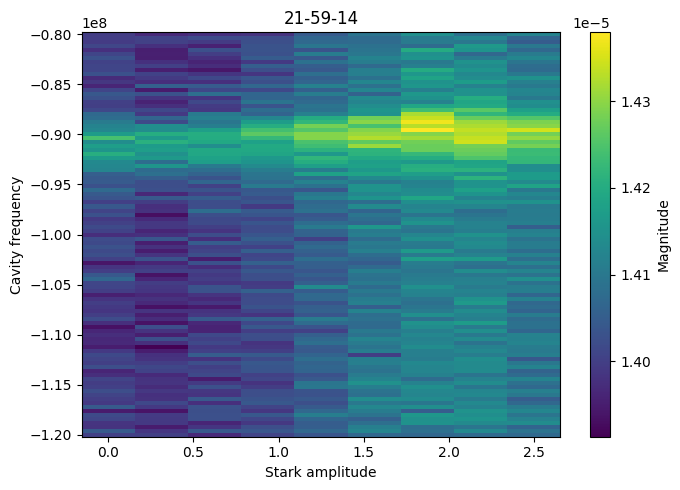

In [6]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

for t, path in files:

    with h5py.File(path, "r") as f:
        mag = f["Magnitude"][()]
        freq = f["cavity_frequency"][()]
        stark = f["stark_ampx"][()]

    # (60000, 101, 9) -> (101, 9)
    Z = np.mean(mag, axis=0)

    plt.figure(figsize=(7, 5))

    plt.pcolormesh(
        stark,
        freq,
        Z,
        shading="auto",
    )

    plt.colorbar(label="Magnitude")
    plt.xlabel("Stark amplitude")
    plt.ylabel("Cavity frequency")
    plt.title(os.path.basename(path)[:8])

    plt.tight_layout()
    plt.show()

In [ ]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

folder = r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-12"

filenames = [
    "18-20-44_Cavity_Spec_stark_shift_2D_Flux.hdf5",
    "18-51-57_Cavity_Spec_stark_shift_2D_Flux.hdf5",
    "19-23-10_Cavity_Spec_stark_shift_2D_Flux.hdf5",
    "19-54-23_Cavity_Spec_stark_shift_2D_Flux.hdf5",
    "20-25-36_Cavity_Spec_stark_shift_2D_Flux.hdf5",
    "20-56-48_Cavity_Spec_stark_shift_2D_Flux.hdf5",
    "21-28-01_Cavity_Spec_stark_shift_2D_Flux.hdf5",
    "21-59-14_Cavity_Spec_stark_shift_2D_Flux.hdf5",
]

flux_values = np.linspace(
    start=0.8e-3,
    stop=1.5e-3,
    num=8
)

print("File -> Flux")
for filename, flux in zip(filenames, flux_values):
    print(f"{filename[:8]} -> {flux*1e3:.3f} mA")


# ==========================================================
# Load and reduce each file
#
# Original:
#   Magnitude.shape = (60000, 101, 9)
#
# After averaging trace axis:
#   (101, 9)
#
# Combined:
#   (8, 101, 9)
#   = (flux, cavity_frequency, stark_ampx)
# ==========================================================

Z_all = []

for filename, flux in zip(filenames, flux_values):

    path = os.path.join(folder, filename)

    with h5py.File(path, "r") as f:
        mag = f["Magnitude"][()]

        cavity_frequency = f["cavity_frequency"][()]
        stark_ampx = f["stark_ampx"][()]

    # 60000 x 101 x 9 -> 101 x 9
    Z = np.mean(mag, axis=0)

    Z_all.append(Z)

Z_all = np.array(Z_all)

print("\nCombined shape:", Z_all.shape)
# should be:
# (8, 101, 9)

File -> Flux
18-20-44 -> 0.800 mA
18-51-57 -> 0.900 mA
19-23-10 -> 1.000 mA
19-54-23 -> 1.100 mA
20-25-36 -> 1.200 mA
20-56-48 -> 1.300 mA
21-28-01 -> 1.400 mA
21-59-14 -> 1.500 mA

Combined shape: (8, 101, 9)


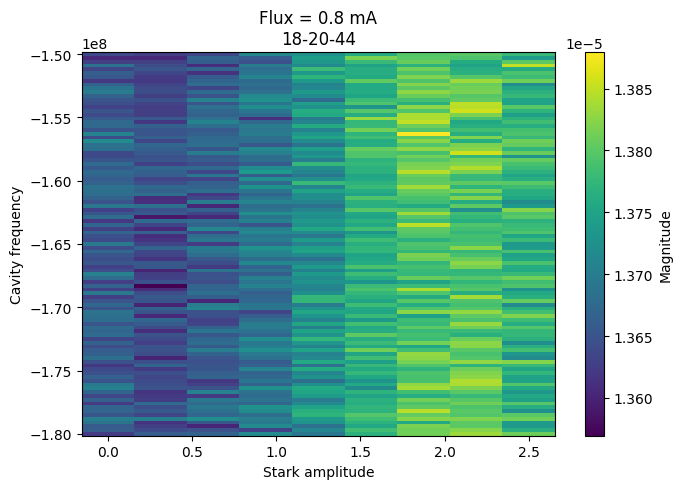

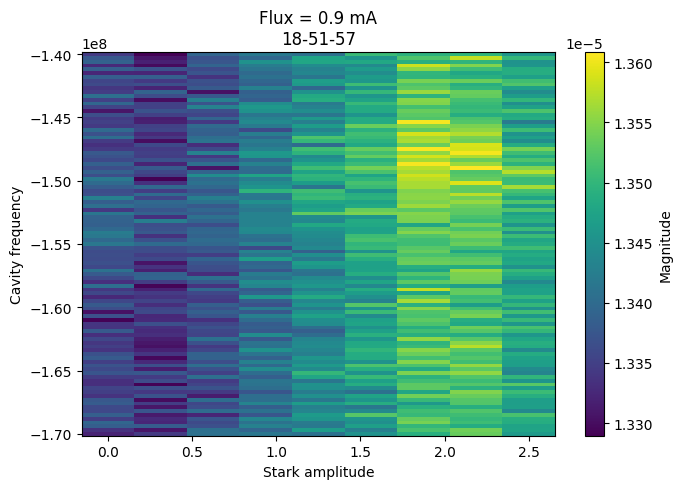

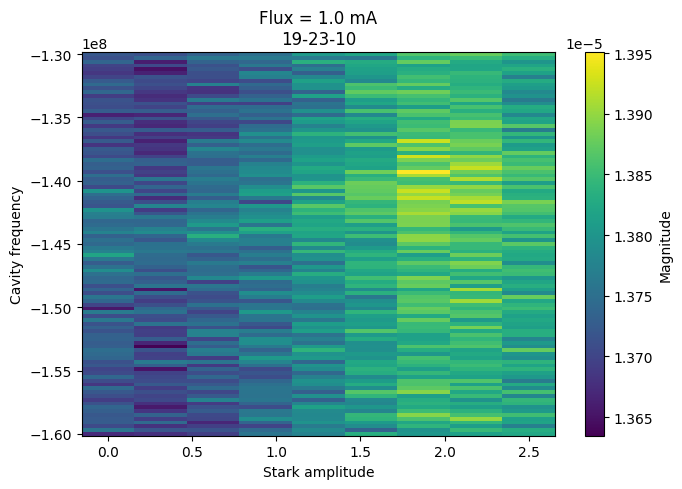

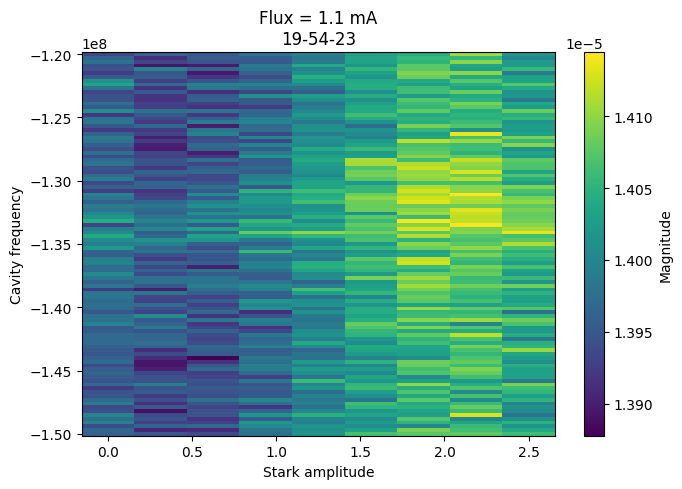

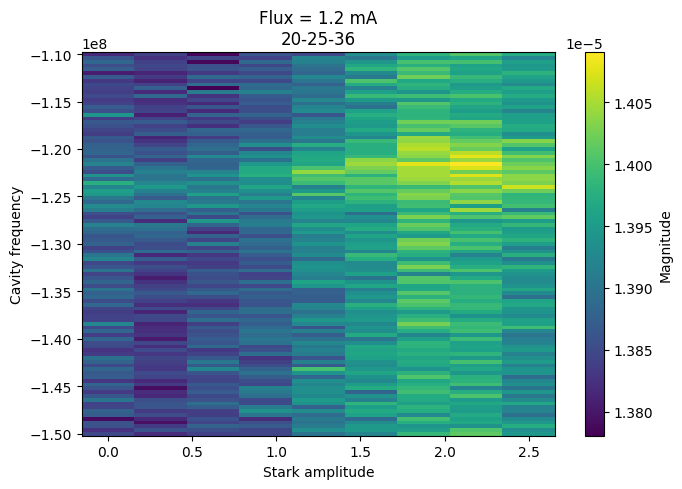

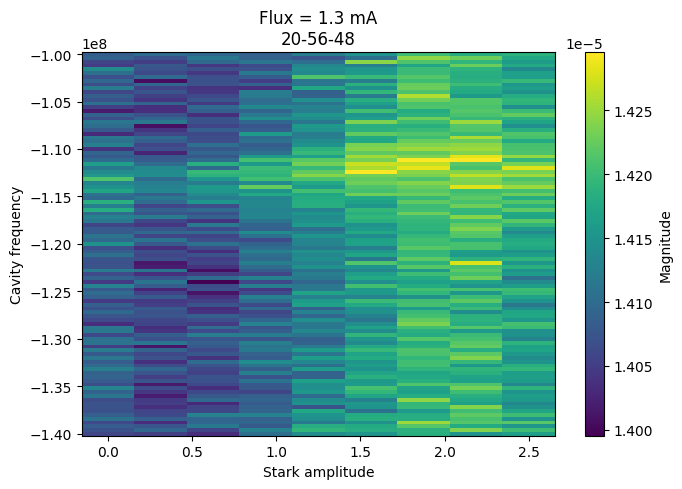

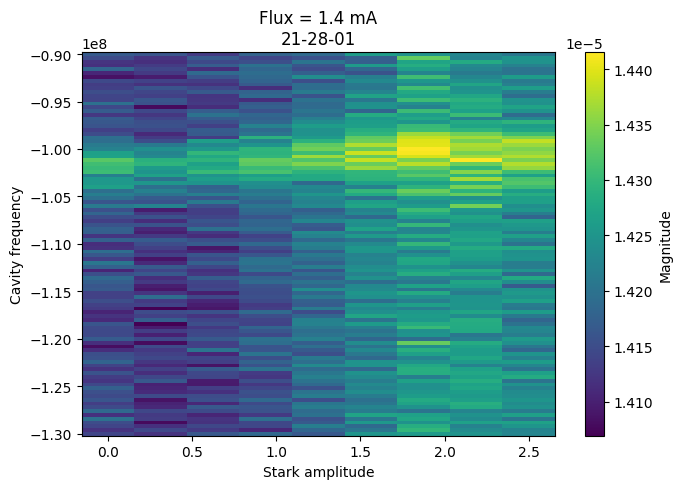

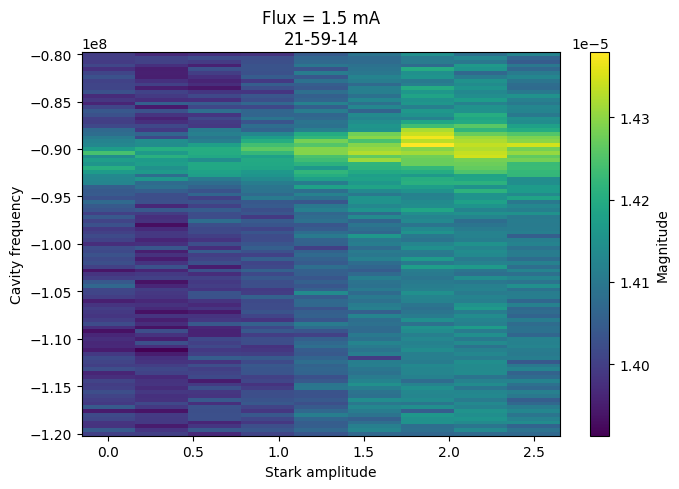

In [8]:
for filename, flux in zip(filenames, flux_values):

    path = os.path.join(folder, filename)

    with h5py.File(path, "r") as f:
        mag = f["Magnitude"][()]
        cavity_frequency = f["cavity_frequency"][()]
        stark_ampx = f["stark_ampx"][()]

    Z = np.mean(mag, axis=0)   # (101, 9)

    plt.figure(figsize=(7, 5))

    plt.pcolormesh(
        stark_ampx,
        cavity_frequency,
        Z,
        shading="auto",
    )

    plt.colorbar(label="Magnitude")
    plt.xlabel("Stark amplitude")
    plt.ylabel("Cavity frequency")

    plt.title(
        f"Flux = {flux*1e3:.1f} mA\n"
        f"{filename[:8]}"
    )

    plt.tight_layout()
    plt.show()